In [1]:
!git clone https://github.com/aliakseizvertouski/olist.git

Cloning into 'olist'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 112 (delta 61), reused 6 (delta 3), pack-reused 14 (from 1)
Receiving objects: 100% (112/112), 42.81 MiB | 10.43 MiB/s, done.
Resolving deltas: 100% (62/62), done.
Updating files: 100% (14/14), done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
customers = pd.read_csv('/content/olist/olist_customers_dataset.csv')
geo = pd.read_csv('/content/olist/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/content/olist/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/olist/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/olist/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/olist/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist/olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('/content/olist/product_category_name_translation.csv')

# Информация о датасете

In [4]:
print (f'customers.columns: {customers.columns} \n')
print (f'geo.columns: {geo.columns} \n')
print (f'order_items.columns: {order_items.columns} \n')
print (f'order_payments.columns: {order_payments.columns} \n')
print (f'order_reviews.columns: {order_reviews.columns} \n')
print (f'orders.columns: {products.columns} \n')
print (f'products.columns: {products.columns} \n')
print (f'sellers.columns: {sellers.columns} \n')
print (f'product_category_name_translation.columns: {product_category_name_translation.columns}')

customers.columns: Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object') 

geo.columns: Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object') 

order_items.columns: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object') 

order_payments.columns: Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object') 

order_reviews.columns: Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object') 

orders.columns: Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'produ

# Анализ анализ зависимости спроса от изменения цены на товар


In [5]:
df_prices = order_items[['order_id', 'order_item_id', 'product_id', 'seller_id', 'price']].merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id'
)

df_prices['purchase_date'] = pd.to_datetime(df_prices['order_purchase_timestamp'])
df_prices = df_prices.sort_values(by=['seller_id', 'product_id', 'purchase_date'])


df_prices['prev_price'] = df_prices.groupby(['seller_id', 'product_id'])['price'].shift(1)
df_prices['discount_percent'] = ((df_prices['prev_price'] - df_prices['price']) / df_prices['prev_price']) * 100
df_prices['discount_percent'] = df_prices['discount_percent'].fillna(0)

# df_prices = df_prices.drop(columns=['order_id'])

def f(arr):
    rank = 0
    values = arr.tolist()
    result = [0] * len(values)
    for idx, value in enumerate(values):
        if value != values[idx - 1]:
            rank += 1
        result[idx] = rank
    return pd.Series(result, index=arr.index)

df_prices['price_period_rank'] = df_prices.groupby(['seller_id', 'product_id'])['price'].transform(f)

df_prices['sales'] = df_prices.groupby(['seller_id', 'product_id', 'price_period_rank'])['price_period_rank'].transform('size')

df_prices = df_prices[df_prices['discount_percent'] != 0]

# df_prices['next_sales'] = df_prices.groupby(['seller_id', 'product_id'])['sales'].shift(-1)

df_prices

,order_id,order_item_id,product_id,seller_id,price,order_purchase_timestamp,purchase_date,prev_price,discount_percent,price_period_rank,sales
85473,c229b75b5de5a2b3a83417c4d5b4343a,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,89.00,2017-04-10 10:41:42,2017-04-10 10:41:42,69.90,-27.324750,2,2
75646,ac3fcd67437432bd0f3a05aade719e7b,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,135.00,2017-05-02 15:23:09,2017-05-02 15:23:09,89.00,-51.685393,3,1
78595,b2c450c7534eb01ae390b7c5668ac39f,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,99.00,2017-05-05 22:12:04,2017-05-05 22:12:04,135.00,26.666667,4,13
25695,3a65edca4808817234bc2f2d84576af3,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,89.00,2017-05-23 11:58:50,2017-05-23 11:58:50,99.00,10.101010,5,25
70829,a198fadedc070d85fe672afa298f1a84,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,99.00,2017-08-14 10:07:18,2017-08-14 10:07:18,89.00,-11.235955,6,60
...,...,...,...,...,...,...,...,...,...,...,...
11109,19419b6180c4c7b9f57c1753cef7b41f,1,7766894470ea995b418764065e6bf9ba,ffc470761de7d0232558ba5e786e57b7,26.68,2018-07-19 11:38:46,2018-07-19 11:38:46,24.98,-6.805444,2,1
45,001ac194d4a326a6fa99b581e9a3d963,1,dbaee28f4ee64465838a229582d77520,ffc470761de7d0232558ba5e786e57b7,54.00,2018-07-04 11:39:11,2018-07-04 11:39:11,54.90,1.639344,2,4
62708,8f2646c107f28bd23a8b8d10764a1660,1,58a96ae04b90563cde5becdf0ee2e823,ffdd9f82b9a447f6f8d4b91554cc7dd3,199.00,2017-10-26 14:49:40,2017-10-26 14:49:40,206.00,3.398058,2,1
103154,ea4286567e0283e5437a80dafadc9a4d,1,ada800a927673ac73cdfbbd2c832331b,ffdd9f82b9a447f6f8d4b91554cc7dd3,63.60,2018-04-17 19:19:04,2018-04-17 19:19:04,53.60,-18.656716,2,2


## Анализ динамики спроса по конкретному товару

In [6]:
# df_prices = df_prices[df_prices['sales'] >= 3]

target_product = 'e251ebd2858be1aa7d9b2087a6992580'
target_seller = '001cca7ae9ae17fb1caed9dfb1094831'

target_seller_data = df_prices[df_prices['seller_id'] == target_seller]
target_product_data = target_seller_data[target_seller_data['product_id'] == target_product]

target_product_data

,order_id,order_item_id,product_id,seller_id,price,order_purchase_timestamp,purchase_date,prev_price,discount_percent,price_period_rank,sales
29319,42aaabf39b810fa0a3390fe791dbb880,1,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,139.9,2017-03-17 14:22:50,2017-03-17 14:22:50,99.9,-40.040040,2,5
37736,55a49914f37572b70e7d0e1fb09f0b1e,1,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,112.0,2017-04-08 18:32:07,2017-04-08 18:32:07,139.9,19.942816,3,5
54694,7c544ec2abdd2f2470ffdaf4215d8706,1,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,139.0,2017-04-17 00:56:11,2017-04-17 00:56:11,112.0,-24.107143,4,3
9071,14bba6d3df6ead296d2626315da5e5d0,1,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,199.0,2017-04-30 15:00:56,2017-04-30 15:00:56,139.0,-43.165468,5,1
48724,6ebaec694d7025e2ad4a05dba887c032,1,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,139.0,2017-05-18 13:55:47,2017-05-18 13:55:47,199.0,30.150754,6,1
49746,711093a34ef24a1588096dbf21f605af,1,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,112.0,2017-05-29 11:26:22,2017-05-29 11:26:22,139.0,19.424460,7,16
98126,de937fa64e3c6113c5a4c20ec533674c,1,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,129.0,2017-08-09 20:46:56,2017-08-09 20:46:56,112.0,-15.178571,8,3


In [7]:
stats = target_product_data[['product_id','seller_id','price', 'discount_percent','sales']]
stats

,product_id,seller_id,price,discount_percent,sales
29319,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,139.9,-40.040040,5
37736,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,112.0,19.942816,5
54694,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,139.0,-24.107143,3
9071,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,199.0,-43.165468,1
48724,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,139.0,30.150754,1
49746,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,112.0,19.424460,16
98126,e251ebd2858be1aa7d9b2087a6992580,001cca7ae9ae17fb1caed9dfb1094831,129.0,-15.178571,3


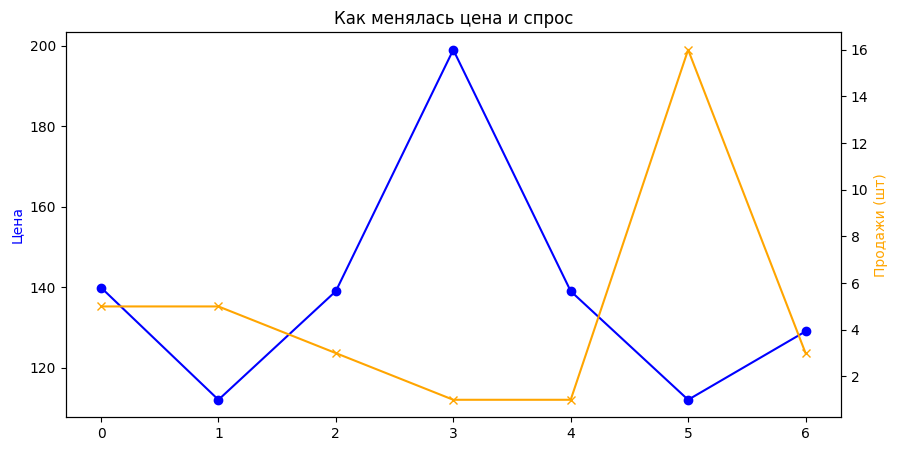

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(stats['price'].values, color='blue', marker='o', label='Цена')
plt.ylabel('Цена', color='blue')

ax2 = plt.twinx()

ax2.plot(stats['sales'].values, color='orange', marker='x', label='Продажи')
ax2.set_ylabel('Продажи (шт)', color='orange')

plt.title('Как менялась цена и спрос')
plt.xlabel('Порядковый номер периода')

plt.show()

## Анализ степени влияния скидок на спрос в зависимости от категории товаров

In [9]:
df_prices['prev_sales'] = df_prices.groupby(['seller_id', 'product_id'])['sales'].shift(1)

df_prices['sales_diff'] = df_prices['sales'] - df_prices['prev_sales']

df_prices['sales_change_percent'] = ((df_prices['sales'] - df_prices['prev_sales']) / df_prices['prev_sales']) * 100

df_prices['sales_change_percent'] = df_prices['sales_change_percent'].fillna(0).round(2)
df_prices['sales_diff'] = df_prices['sales_diff'].fillna(0)

df_prices = df_prices.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

df_prices = df_prices.merge(
    product_category_name_translation,
    on='product_category_name',
    how='left'
)

# df_prices = df_prices.drop(columns=['product_category_name'])

# df_prices = df_prices.drop(columns=['product_category_name'])
df_prices = df_prices.rename(columns={'product_category_name_english': 'product_category'})
df_prices = df_prices[['order_id', 'order_item_id', 'product_id', 'seller_id', 'product_category',
                       'purchase_date', 'price', 'prev_price', 'discount_percent', 'price_period_rank', 'sales', 'prev_sales', 'sales_change_percent']]

df_prices

,order_id,order_item_id,product_id,seller_id,product_category,purchase_date,price,prev_price,discount_percent,price_period_rank,sales,prev_sales,sales_change_percent
0,c229b75b5de5a2b3a83417c4d5b4343a,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,garden_tools,2017-04-10 10:41:42,89.00,69.90,-27.324750,2,2,NaN,0.00
1,ac3fcd67437432bd0f3a05aade719e7b,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,garden_tools,2017-05-02 15:23:09,135.00,89.00,-51.685393,3,1,2.0,-50.00
2,b2c450c7534eb01ae390b7c5668ac39f,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,garden_tools,2017-05-05 22:12:04,99.00,135.00,26.666667,4,13,1.0,1200.00
3,3a65edca4808817234bc2f2d84576af3,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,garden_tools,2017-05-23 11:58:50,89.00,99.00,10.101010,5,25,13.0,92.31
4,a198fadedc070d85fe672afa298f1a84,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,garden_tools,2017-08-14 10:07:18,99.00,89.00,-11.235955,6,60,25.0,140.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8572,19419b6180c4c7b9f57c1753cef7b41f,1,7766894470ea995b418764065e6bf9ba,ffc470761de7d0232558ba5e786e57b7,housewares,2018-07-19 11:38:46,26.68,24.98,-6.805444,2,1,NaN,0.00
8573,001ac194d4a326a6fa99b581e9a3d963,1,dbaee28f4ee64465838a229582d77520,ffc470761de7d0232558ba5e786e57b7,construction_tools_construction,2018-07-04 11:39:11,54.00,54.90,1.639344,2,4,NaN,0.00
8574,8f2646c107f28bd23a8b8d10764a1660,1,58a96ae04b90563cde5becdf0ee2e823,ffdd9f82b9a447f6f8d4b91554cc7dd3,furniture_decor,2017-10-26 14:49:40,199.00,206.00,3.398058,2,1,NaN,0.00
8575,ea4286567e0283e5437a80dafadc9a4d,1,ada800a927673ac73cdfbbd2c832331b,ffdd9f82b9a447f6f8d4b91554cc7dd3,housewares,2018-04-17 19:19:04,63.60,53.60,-18.656716,2,2,NaN,0.00


In [12]:
df_prices.to_csv('df_prices_full.csv', index=False, sep=';')

In [10]:
df_discounts = df_prices[df_prices['discount_percent'] > 0]

category_impact = df_discounts.groupby('product_category').agg(
    avg_sales_change=('sales_change_percent', 'mean'),                # ср рост продаж
    avg_discount=('discount_percent', 'mean'),                        # ср размер скидки
    discount_events=('product_id', 'count')                           # к-во скидок
).reset_index()


category_impact = category_impact[category_impact['discount_events'] >= 5]

top_categories = category_impact.sort_values(by='avg_sales_change', ascending=False)

top_categories.head(10)

,product_category,avg_sales_change,avg_discount,discount_events
11,computers,287.300000,7.685684,6
15,construction_tools_lights,228.202727,14.006143,11
33,garden_tools,115.682771,14.494603,83
21,drinks,112.222222,22.516512,9
5,auto,96.507281,9.539310,114
45,office_furniture,85.010000,6.929756,154
12,computers_accessories,83.893910,10.037627,312
53,stationery,81.699157,11.901572,83
22,electronics,78.878710,12.864962,62
57,watches_gifts,78.300000,8.500028,342


In [11]:
top_categories.to_csv('tableau_data.csv', index=False)